##Loan Default Risk Prediction using Machine Learning

uploading dataset file

In [ ]:
from google.colab import files
files.upload()

##importing dependent lybraries


In [351]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

##loading the dataset

In [352]:
df=pd.read_csv('/content/LoanDataset - LoansDatasest.csv')

In [353]:
df.head()

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
0,1.0,22,59000,RENT,123.0,PERSONAL,C,"£35,000.00",16.02,10,Y,3,DEFAULT
1,2.0,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,NaN,2,NO DEFAULT
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT
3,4.0,23,65500,RENT,4.0,MEDICAL,B,"£35,000.00",15.23,10,N,2,DEFAULT
4,5.0,24,54400,RENT,8.0,MEDICAL,B,"£35,000.00",14.27,10,Y,4,DEFAULT


##checkinng the null values to perform cleaning on the dataset

In [354]:
df.isnull().sum()

,0
customer_id,3
customer_age,0
customer_income,0
home_ownership,0
employment_duration,895
loan_intent,0
loan_grade,0
loan_amnt,1
loan_int_rate,3116
term_years,0


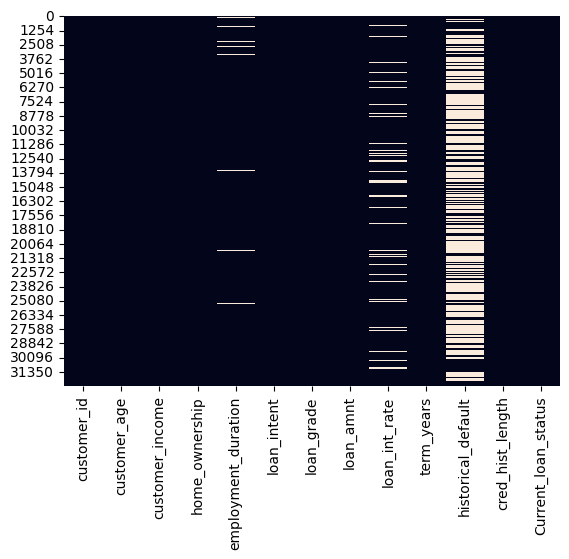

In [355]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [356]:
df.head()

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
0,1.0,22,59000,RENT,123.0,PERSONAL,C,"£35,000.00",16.02,10,Y,3,DEFAULT
1,2.0,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,NaN,2,NO DEFAULT
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT
3,4.0,23,65500,RENT,4.0,MEDICAL,B,"£35,000.00",15.23,10,N,2,DEFAULT
4,5.0,24,54400,RENT,8.0,MEDICAL,B,"£35,000.00",14.27,10,Y,4,DEFAULT


#Performing EDA

In [357]:
df['customer_id'].isnull().value_counts()

,count
customer_id,
False,32583
True,3


In [358]:
null_index = df[df['customer_id'].isnull()].index
null_index

Index([25559, 25560, 25561], dtype='int64')

In [359]:
df.drop(null_index,inplace=True)

In [360]:
df['customer_id'].isnull().sum()

np.int64(0)

##customer_id column is cleaned now,

In [361]:
df = df.dropna(subset=['loan_amnt'])

In [362]:
df.isnull().sum()

,0
customer_id,0
customer_age,0
customer_income,0
home_ownership,0
employment_duration,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3114
term_years,0


In [363]:
df['employment_duration'].describe()

,employment_duration
count,31687.000000
mean,4.790166
std,4.142928
min,0.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,123.000000


##employment_duration has max outlier value 123 as employment duration years and there are lot of null values so filled those with median

In [364]:
df['employment_duration'].fillna(df['employment_duration'].median(),inplace=True)

/tmp/ipykernel_5312/2197446330.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['employment_duration'].fillna(df['employment_duration'].median(),inplace=True)


In [365]:
df['employment_duration'].describe()

,employment_duration
count,32582.000000
mean,4.768461
std,4.087669
min,0.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,123.000000


In [366]:
df['employment_duration'].isnull().sum()

np.int64(0)

<Axes: >

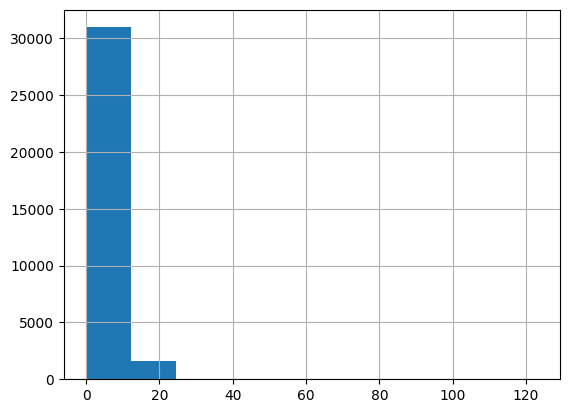

In [367]:
df['employment_duration'].hist()

##The skewness of the data is in right the value>1 which need to minimize

In [368]:
df['employment_duration'].skew()

np.float64(2.662360464902062)

##droping customer_id column as it has no importance for training

In [369]:
df.drop(columns=['customer_id'],axis=1,inplace=True)

In [370]:
df['employment_duration'].describe()

,employment_duration
count,32582.000000
mean,4.768461
std,4.087669
min,0.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,123.000000


##eliminate the outlier value so in result skewness of data will reduce

In [371]:
df = df[df['employment_duration'] != 123]

In [372]:
df['employment_duration'].describe()

,employment_duration
count,32580.000000
mean,4.761203
std,3.981441
min,0.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,41.000000


In [373]:
df['employment_duration'].skew()

np.float64(1.2791709387086116)

In [374]:
df.head()

,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
1,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,NaN,2,NO DEFAULT
2,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT
3,23,65500,RENT,4.0,MEDICAL,B,"£35,000.00",15.23,10,N,2,DEFAULT
4,24,54400,RENT,8.0,MEDICAL,B,"£35,000.00",14.27,10,Y,4,DEFAULT
5,21,9900,OWN,2.0,VENTURE,A,"£2,500.00",7.14,1,N,2,DEFAULT


In [375]:
df.isnull().sum()

,0
customer_age,0
customer_income,0
home_ownership,0
employment_duration,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3114
term_years,0
historical_default,20734


In [376]:
df['loan_int_rate'].describe()

,loan_int_rate
count,29466.000000
mean,11.011472
std,3.240413
min,5.420000
25%,7.900000
50%,10.990000
75%,13.470000
max,23.220000


##fiiling null values in loan interest rate with median value

In [377]:
df['loan_int_rate']=df['loan_int_rate'].fillna(df['loan_int_rate'].median())

In [378]:
df['loan_int_rate'].describe()

,loan_int_rate
count,32580.000000
mean,11.009419
std,3.081666
min,5.420000
25%,8.490000
50%,10.990000
75%,13.110000
max,23.220000


In [379]:
df['loan_int_rate'].skew()

np.float64(0.22140307463009634)

In [380]:
df.isnull().sum()

,0
customer_age,0
customer_income,0
home_ownership,0
employment_duration,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
term_years,0
historical_default,20734


In [381]:
df['historical_default'].describe()

,historical_default
count,11846
unique,2
top,Y
freq,6126


In [382]:
df['historical_default'].value_counts()

,count
historical_default,
Y,6126
N,5720


##the null values in historical deafult column will be filled with 'unknown' and store the data in a new column

In [383]:
df['historical_default_missing']=df['historical_default'].isnull().astype(int)

In [384]:
df['historical_default'].fillna('unknown',inplace=True)

/tmp/ipykernel_5312/4212243147.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['historical_default'].fillna('unknown',inplace=True)


In [385]:
df

,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status,historical_default_missing
1,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,unknown,2,NO DEFAULT,1
2,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT,0
3,23,65500,RENT,4.0,MEDICAL,B,"£35,000.00",15.23,10,N,2,DEFAULT,0
4,24,54400,RENT,8.0,MEDICAL,B,"£35,000.00",14.27,10,Y,4,DEFAULT,0
5,21,9900,OWN,2.0,VENTURE,A,"£2,500.00",7.14,1,N,2,DEFAULT,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32581,57,53000,MORTGAGE,1.0,PERSONAL,C,"£5,800.00",13.16,7,unknown,30,NO DEFAULT,1
32582,54,120000,MORTGAGE,4.0,PERSONAL,A,"£17,625.00",7.49,4,unknown,19,NO DEFAULT,1
32583,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,"£35,000.00",10.99,5,N,28,DEFAULT,0
32584,56,150000,MORTGAGE,5.0,PERSONAL,B,"£15,000.00",11.48,6,unknown,26,NO DEFAULT,1


##as model will understand and work on numeric value so encoded the historical default column value and map those to numeric value

In [386]:
df['historical_default_encoded']=df['historical_default'].map({
    'Y':1,
    'N':0,
    'unknown':-1
})

In [387]:
df

,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status,historical_default_missing,historical_default_encoded
1,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,unknown,2,NO DEFAULT,1,-1
2,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT,0,0
3,23,65500,RENT,4.0,MEDICAL,B,"£35,000.00",15.23,10,N,2,DEFAULT,0,0
4,24,54400,RENT,8.0,MEDICAL,B,"£35,000.00",14.27,10,Y,4,DEFAULT,0,1
5,21,9900,OWN,2.0,VENTURE,A,"£2,500.00",7.14,1,N,2,DEFAULT,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32581,57,53000,MORTGAGE,1.0,PERSONAL,C,"£5,800.00",13.16,7,unknown,30,NO DEFAULT,1,-1
32582,54,120000,MORTGAGE,4.0,PERSONAL,A,"£17,625.00",7.49,4,unknown,19,NO DEFAULT,1,-1
32583,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,"£35,000.00",10.99,5,N,28,DEFAULT,0,0
32584,56,150000,MORTGAGE,5.0,PERSONAL,B,"£15,000.00",11.48,6,unknown,26,NO DEFAULT,1,-1


In [388]:
df.head()

,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status,historical_default_missing,historical_default_encoded
1,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,unknown,2,NO DEFAULT,1,-1
2,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT,0,0
3,23,65500,RENT,4.0,MEDICAL,B,"£35,000.00",15.23,10,N,2,DEFAULT,0,0
4,24,54400,RENT,8.0,MEDICAL,B,"£35,000.00",14.27,10,Y,4,DEFAULT,0,1
5,21,9900,OWN,2.0,VENTURE,A,"£2,500.00",7.14,1,N,2,DEFAULT,0,0


In [389]:
df.isnull().sum()

,0
customer_age,0
customer_income,0
home_ownership,0
employment_duration,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
term_years,0
historical_default,0


##EDA performing on the output/target column- 'current_loan_status'

In [390]:
null_index1=df[df['Current_loan_status'].isnull()].index

In [391]:
df.drop(null_index1,inplace=True)

In [392]:
df['Current_loan_status'].describe()

,Current_loan_status
count,32576
unique,2
top,NO DEFAULT
freq,25739


In [393]:
df['Current_loan_status'].value_counts()

,count
Current_loan_status,
NO DEFAULT,25739
DEFAULT,6837


<Axes: >

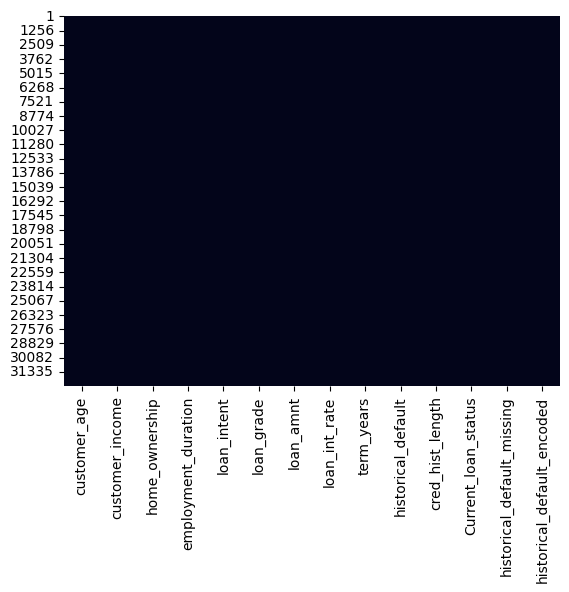

In [394]:
sns.heatmap(df.isnull(),cbar=False)

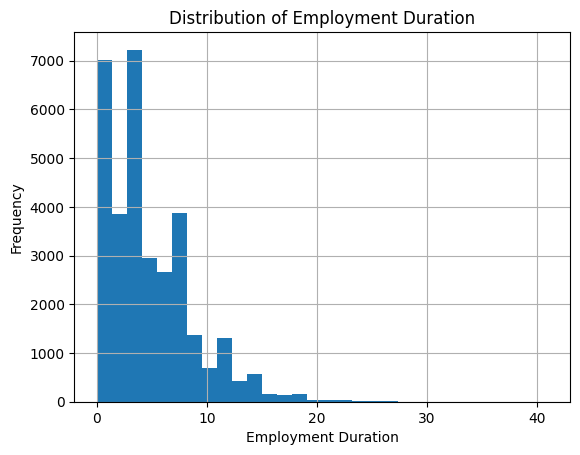

In [395]:

df['employment_duration'].hist(bins=30)
plt.title("Distribution of Employment Duration")
plt.xlabel("Employment Duration")
plt.ylabel("Frequency")
plt.show()

##perfing log(1+x) math operation on employment_duration column to reduce skewness

In [396]:
df['employment_duration'] = np.log1p(df['employment_duration'])

In [397]:
df['employment_duration'].skew()

np.float64(-0.4775634682103134)

clean visualization of data distribution of employment duration

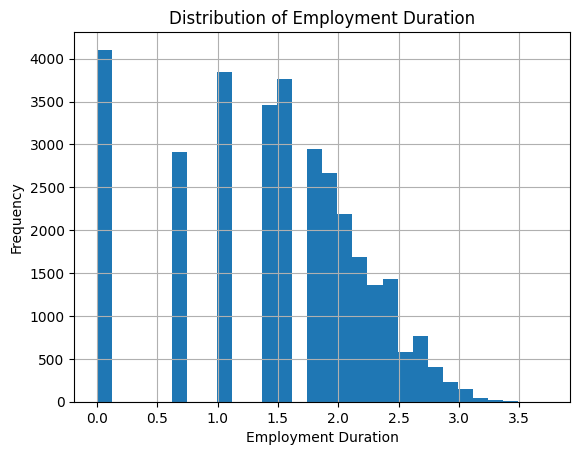

In [398]:
df['employment_duration'].hist(bins=30)
plt.title("Distribution of Employment Duration")
plt.xlabel("Employment Duration")
plt.ylabel("Frequency")
plt.show()

##map the values of target column to convert from 'str' to numeric

In [399]:

df['current_loan_status_encoded']=df['Current_loan_status'].map({
    'DEFAULT':1,
    'NO DEFAULT':0
})

In [400]:
df.head()

,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status,historical_default_missing,historical_default_encoded,current_loan_status_encoded
1,21,9600,OWN,1.791759,EDUCATION,A,"£1,000.00",11.14,1,unknown,2,NO DEFAULT,1,-1,0
2,25,9600,MORTGAGE,0.693147,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT,0,0,1
3,23,65500,RENT,1.609438,MEDICAL,B,"£35,000.00",15.23,10,N,2,DEFAULT,0,0,1
4,24,54400,RENT,2.197225,MEDICAL,B,"£35,000.00",14.27,10,Y,4,DEFAULT,0,1,1
5,21,9900,OWN,1.098612,VENTURE,A,"£2,500.00",7.14,1,N,2,DEFAULT,0,0,1


In [401]:
df['loan_grade'].value_counts()

,count
loan_grade,
A,15659
B,9060
C,4924
D,2628
E,305


##mapping loan grade values

In [402]:
grade_map={'A':1,'B':2,'C':3,'D':4,'E':5}
df['loan_grade']=df['loan_grade'].map(grade_map)

In [403]:
df=pd.get_dummies(df,columns=['loan_intent'],drop_first=True)

In [404]:
df['home_ownership'].value_counts()

,count
home_ownership,
RENT,16446
MORTGAGE,13440
OWN,2583
OTHER,107


In [405]:
df=pd.get_dummies(df,columns=['home_ownership'],drop_first=True)

In [406]:
df.head()

,customer_age,customer_income,employment_duration,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status,...,historical_default_encoded,current_loan_status_encoded,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT
1,21,9600,1.791759,1,"£1,000.00",11.14,1,unknown,2,NO DEFAULT,...,-1,0,True,False,False,False,False,False,True,False
2,25,9600,0.693147,2,"£5,500.00",12.87,5,N,3,DEFAULT,...,0,1,False,False,True,False,False,False,False,False
3,23,65500,1.609438,2,"£35,000.00",15.23,10,N,2,DEFAULT,...,0,1,False,False,True,False,False,False,False,True
4,24,54400,2.197225,2,"£35,000.00",14.27,10,Y,4,DEFAULT,...,1,1,False,False,True,False,False,False,False,True
5,21,9900,1.098612,1,"£2,500.00",7.14,1,N,2,DEFAULT,...,0,1,False,False,False,False,True,False,True,False


In [407]:
df.describe()

,customer_age,employment_duration,loan_grade,loan_int_rate,term_years,cred_hist_length,historical_default_missing,historical_default_encoded,current_loan_status_encoded
count,32576.000000,32576.000000,32576.000000,32576.000000,32576.000000,32576.000000,32576.000000,32576.000000,32576.000000
mean,27.733086,1.488158,1.859897,11.009303,4.761143,5.803843,0.636481,-0.448428,0.209878
std,6.361213,0.778381,1.009556,3.081719,2.470669,4.055405,0.481020,0.789598,0.407228
min,3.000000,0.000000,1.000000,5.420000,1.000000,2.000000,0.000000,-1.000000,0.000000
25%,23.000000,1.098612,1.000000,8.490000,3.000000,3.000000,0.000000,-1.000000,0.000000
50%,26.000000,1.609438,2.000000,10.990000,4.000000,4.000000,1.000000,-1.000000,0.000000
75%,30.000000,2.079442,2.000000,13.110000,7.000000,8.000000,1.000000,0.000000,0.000000
max,144.000000,3.737670,5.000000,23.220000,10.000000,30.000000,1.000000,1.000000,1.000000


##there are '£'string in loan_amnt column values so the ('£') str need to replace with a null str ('') it have to convert from str to float

In [408]:
df['loan_amnt'] = df['loan_amnt'].astype(str).str.replace('£', '').str.replace(',', '').astype(float)

I take help from Toggle gemini to perform that above step

In [409]:
df.head()

,customer_age,customer_income,employment_duration,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status,...,historical_default_encoded,current_loan_status_encoded,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT
1,21,9600,1.791759,1,1000.0,11.14,1,unknown,2,NO DEFAULT,...,-1,0,True,False,False,False,False,False,True,False
2,25,9600,0.693147,2,5500.0,12.87,5,N,3,DEFAULT,...,0,1,False,False,True,False,False,False,False,False
3,23,65500,1.609438,2,35000.0,15.23,10,N,2,DEFAULT,...,0,1,False,False,True,False,False,False,False,True
4,24,54400,2.197225,2,35000.0,14.27,10,Y,4,DEFAULT,...,1,1,False,False,True,False,False,False,False,True
5,21,9900,1.098612,1,2500.0,7.14,1,N,2,DEFAULT,...,0,1,False,False,False,False,True,False,True,False


In [410]:
df.columns

Index(['customer_age', 'customer_income', 'employment_duration', 'loan_grade',
       'loan_amnt', 'loan_int_rate', 'term_years', 'historical_default',
       'cred_hist_length', 'Current_loan_status', 'historical_default_missing',
       'historical_default_encoded', 'current_loan_status_encoded',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT'],
      dtype='object')

In [411]:
df['customer_income'].value_counts()

,count
customer_income,
60000,1044
30000,847
50000,778
40000,658
45000,589
...,...
62046,1
46560,1
90750,1


In [412]:
df['customer_income'].value_counts(250,000)

,proportion
customer_income,
9600,0.000675
65500,0.000246
54400,0.000706
9900,0.000031
77100,0.000092
...,...
115900,0.000031
39240,0.000031
720000,0.000031


In [413]:
df[df['customer_income'].str.contains(',')]


,customer_age,customer_income,employment_duration,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status,...,historical_default_encoded,current_loan_status_encoded,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT
29164,36,"250,000",1.098612,1,20000.0,7.88,6,N,17,DEFAULT,...,0,1,False,False,False,False,False,False,False,True
29358,37,"103,000",1.386294,1,18550.0,7.88,7,N,12,DEFAULT,...,0,1,False,False,False,False,False,False,False,True
30727,40,"164,000",2.484907,1,8000.0,10.99,4,N,17,DEFAULT,...,0,1,False,False,False,False,False,False,False,True
32337,51,"45,000",0.693147,1,16000.0,7.90,1,N,19,DEFAULT,...,0,1,False,False,False,False,False,False,False,True


##Same operation done to conver replace',' str to null str " " and make customer_income column in float values

In [414]:
df['customer_income']=df['customer_income'].str.replace(',','').astype(float)

In [415]:
df['customer_income'].astype(float)

,customer_income
1,9600.0
2,9600.0
3,65500.0
4,54400.0
5,9900.0
...,...
32581,53000.0
32582,120000.0
32583,76000.0
32584,150000.0


##Performing Feature Engineering and make new feature as customer_income_category

In [416]:
def customer_income_cat(value):

    if value >=60000:
      return 'A'
    elif value <60000 and value >=45000:
      return 'B'
    elif value <45000 and value >=30000:
       return 'C'
    elif value <30000 and value >=15000:
      return 'D'
    else:
      return 'E'



In [417]:
df['customer_income_category']=df['customer_income'].apply(customer_income_cat)

In [418]:
df.head()

,customer_age,customer_income,employment_duration,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status,...,current_loan_status_encoded,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,customer_income_category
1,21,9600.0,1.791759,1,1000.0,11.14,1,unknown,2,NO DEFAULT,...,0,True,False,False,False,False,False,True,False,E
2,25,9600.0,0.693147,2,5500.0,12.87,5,N,3,DEFAULT,...,1,False,False,True,False,False,False,False,False,E
3,23,65500.0,1.609438,2,35000.0,15.23,10,N,2,DEFAULT,...,1,False,False,True,False,False,False,False,True,A
4,24,54400.0,2.197225,2,35000.0,14.27,10,Y,4,DEFAULT,...,1,False,False,True,False,False,False,False,True,B
5,21,9900.0,1.098612,1,2500.0,7.14,1,N,2,DEFAULT,...,1,False,False,False,False,True,False,True,False,E


##Make new feature as Loan vs Income ratio

In [419]:
df['loan_vs_income_ratio']=df['loan_amnt']/df['customer_income']

In [420]:
df.columns

Index(['customer_age', 'customer_income', 'employment_duration', 'loan_grade',
       'loan_amnt', 'loan_int_rate', 'term_years', 'historical_default',
       'cred_hist_length', 'Current_loan_status', 'historical_default_missing',
       'historical_default_encoded', 'current_loan_status_encoded',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT',
       'customer_income_category', 'loan_vs_income_ratio'],
      dtype='object')

In [421]:
df=pd.get_dummies(df,columns=['customer_income_category'],drop_first=True)

In [422]:
df.dtypes

,0
customer_age,int64
customer_income,float64
employment_duration,float64
loan_grade,int64
loan_amnt,float64
loan_int_rate,float64
term_years,int64
historical_default,object
cred_hist_length,int64
Current_loan_status,object


In [423]:
df=df.drop(columns=['historical_default','Current_loan_status'],axis=1)

In [424]:
df.dtypes

,0
customer_age,int64
customer_income,float64
employment_duration,float64
loan_grade,int64
loan_amnt,float64
loan_int_rate,float64
term_years,int64
cred_hist_length,int64
historical_default_missing,int64
historical_default_encoded,int64


checking coorelation values among each column





In [425]:
df.corr()

,customer_age,customer_income,employment_duration,loan_grade,loan_amnt,loan_int_rate,term_years,cred_hist_length,historical_default_missing,historical_default_encoded,...,loan_intent_PERSONAL,loan_intent_VENTURE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_vs_income_ratio,customer_income_category_B,customer_income_category_C,customer_income_category_D,customer_income_category_E
customer_age,1.000000,0.173140,0.077656,0.215739,0.014426,0.011993,0.136270,0.857483,-0.150748,0.091169,...,0.033641,-0.011981,-0.008387,-0.001617,-0.029664,-0.015142,-0.019849,-0.046947,-0.038130,-0.022229
customer_income,0.173140,1.000000,0.116266,0.015347,0.080217,0.000825,0.059423,0.117991,0.083434,-0.058621,...,0.012978,0.002195,0.009554,-0.039000,-0.180370,-0.088219,-0.119694,-0.254997,-0.227933,-0.099665
employment_duration,0.077656,0.116266,1.000000,-0.033190,0.034579,-0.055454,0.056070,0.066907,0.065448,-0.058297,...,0.009370,0.006330,-0.019630,0.017521,-0.227172,-0.013742,0.022996,-0.082793,-0.137193,-0.070754
loan_grade,0.215739,0.015347,-0.033190,1.000000,0.030252,0.785369,0.100809,0.232634,-0.507119,0.546401,...,-0.001533,-0.012405,0.016470,-0.019932,0.119028,0.032000,-0.013376,0.031476,0.019425,0.016633
loan_amnt,0.014426,0.080217,0.034579,0.030252,1.000000,0.036870,0.077421,0.009841,-0.022489,0.016021,...,0.009164,-0.003657,0.003480,-0.009769,-0.026115,0.943598,-0.018164,-0.054957,-0.066464,-0.034639
loan_int_rate,0.011993,0.000825,-0.055454,0.785369,0.036870,1.000000,0.041603,0.015672,-0.449436,0.494586,...,-0.001866,-0.008429,0.016670,-0.013076,0.131580,0.038656,-0.008015,0.027829,0.017699,0.009525
term_years,0.136270,0.059423,0.056070,0.100809,0.077421,0.041603,1.000000,0.182500,-0.048188,0.034270,...,0.007023,-0.005641,-0.001399,-0.002807,-0.008245,0.061234,0.031289,-0.042215,-0.087404,-0.049586
cred_hist_length,0.857483,0.117991,0.066907,0.232634,0.009841,0.015672,0.182500,1.000000,-0.157477,0.094445,...,0.035324,-0.008951,-0.006749,0.004557,-0.025783,-0.012570,-0.016876,-0.037431,-0.025212,-0.016142
historical_default_missing,-0.150748,0.083434,0.065448,-0.507119,-0.022489,-0.449436,-0.048188,-0.157477,1.000000,-0.924340,...,0.007979,0.048804,-0.015731,0.065891,-0.195493,-0.088416,0.012917,-0.070477,-0.114593,-0.100960
historical_default_encoded,0.091169,-0.058621,-0.058297,0.546401,0.016021,0.494586,0.034270,0.094445,-0.924340,1.000000,...,-0.012912,-0.026962,0.016975,-0.045427,0.158851,0.060334,-0.013776,0.058986,0.082734,0.070968


In [426]:

df.skew()

,0
customer_age,2.599753
customer_income,32.866451
employment_duration,-0.477563
loan_grade,0.971724
loan_amnt,132.243038
loan_int_rate,0.221434
term_years,0.274234
cred_hist_length,1.661939
historical_default_missing,-0.567499
historical_default_encoded,0.976061


In [427]:
df.head()

,customer_age,customer_income,employment_duration,loan_grade,loan_amnt,loan_int_rate,term_years,cred_hist_length,historical_default_missing,historical_default_encoded,...,loan_intent_PERSONAL,loan_intent_VENTURE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_vs_income_ratio,customer_income_category_B,customer_income_category_C,customer_income_category_D,customer_income_category_E
1,21,9600.0,1.791759,1,1000.0,11.14,1,2,1,-1,...,False,False,False,True,False,0.104167,False,False,False,True
2,25,9600.0,0.693147,2,5500.0,12.87,5,3,0,0,...,False,False,False,False,False,0.572917,False,False,False,True
3,23,65500.0,1.609438,2,35000.0,15.23,10,2,0,0,...,False,False,False,False,True,0.534351,False,False,False,False
4,24,54400.0,2.197225,2,35000.0,14.27,10,4,0,1,...,False,False,False,False,True,0.643382,True,False,False,False
5,21,9900.0,1.098612,1,2500.0,7.14,1,2,0,0,...,False,True,False,True,False,0.252525,False,False,False,True


##Feature engineering: Add new featutre as Loan amount load on each customer

In [428]:
df['load_of_loan_yearly']=df['loan_amnt']/df['term_years']

In [429]:
df[['loan_amnt', 'loan_int_rate', 'term_years']].dtypes

,0
loan_amnt,float64
loan_int_rate,float64
term_years,int64


##convert the loa_amnt value in decimal

In [430]:
df['loan_int_rate_decimal']=df['loan_int_rate']/100

In [431]:
df['loan_int_rate_decimal']

,loan_int_rate_decimal
1,0.1114
2,0.1287
3,0.1523
4,0.1427
5,0.0714
...,...
32581,0.1316
32582,0.0749
32583,0.1099
32584,0.1148


In [432]:
df['Total_loan_paid_with_interest']=df['loan_amnt']*df['loan_int_rate']*df['term_years']

In [433]:
df.head()

,customer_age,customer_income,employment_duration,loan_grade,loan_amnt,loan_int_rate,term_years,cred_hist_length,historical_default_missing,historical_default_encoded,...,home_ownership_OWN,home_ownership_RENT,loan_vs_income_ratio,customer_income_category_B,customer_income_category_C,customer_income_category_D,customer_income_category_E,load_of_loan_yearly,loan_int_rate_decimal,Total_loan_paid_with_interest
1,21,9600.0,1.791759,1,1000.0,11.14,1,2,1,-1,...,True,False,0.104167,False,False,False,True,1000.0,0.1114,11140.0
2,25,9600.0,0.693147,2,5500.0,12.87,5,3,0,0,...,False,False,0.572917,False,False,False,True,1100.0,0.1287,353925.0
3,23,65500.0,1.609438,2,35000.0,15.23,10,2,0,0,...,False,True,0.534351,False,False,False,False,3500.0,0.1523,5330500.0
4,24,54400.0,2.197225,2,35000.0,14.27,10,4,0,1,...,False,True,0.643382,True,False,False,False,3500.0,0.1427,4994500.0
5,21,9900.0,1.098612,1,2500.0,7.14,1,2,0,0,...,True,False,0.252525,False,False,False,True,2500.0,0.0714,17850.0


In [434]:
df.drop(columns=['loan_int_rate'],axis=1,inplace=True)

In [435]:
df.describe()

,customer_age,customer_income,employment_duration,loan_grade,loan_amnt,term_years,cred_hist_length,historical_default_missing,historical_default_encoded,current_loan_status_encoded,loan_vs_income_ratio,load_of_loan_yearly,loan_int_rate_decimal,Total_loan_paid_with_interest
count,32576.000000,3.257600e+04,32576.000000,32576.000000,3.257600e+04,32576.000000,32576.000000,32576.000000,32576.000000,32576.000000,32576.000000,32576.000000,32576.000000,3.257600e+04
mean,27.733086,6.607151e+04,1.488158,1.859897,9.754752e+03,4.761143,5.803843,0.636481,-0.448428,0.209878,0.172562,2776.208454,0.110093,5.734324e+05
std,6.361213,6.198556e+04,0.778381,1.009556,2.177415e+04,2.470669,4.055405,0.481020,0.789598,0.407228,0.301138,3730.291246,0.030817,1.873175e+06
min,3.000000,4.000000e+03,0.000000,1.000000,5.000000e+02,1.000000,2.000000,0.000000,-1.000000,0.000000,0.000789,83.333333,0.054200,5.896000e+03
25%,23.000000,3.850000e+04,1.098612,1.000000,5.000000e+03,3.000000,3.000000,0.000000,-1.000000,0.000000,0.089577,1111.111111,0.084900,1.566056e+05
50%,26.000000,5.500000e+04,1.609438,2.000000,8.000000e+03,4.000000,4.000000,1.000000,-1.000000,0.000000,0.148148,1966.666667,0.109900,3.297000e+05
75%,30.000000,7.920000e+04,2.079442,2.000000,1.220000e+04,7.000000,8.000000,1.000000,0.000000,0.000000,0.229167,3250.000000,0.131100,7.116000e+05
max,144.000000,6.000000e+06,3.737670,5.000000,3.500000e+06,10.000000,30.000000,1.000000,1.000000,1.000000,49.645390,388888.888889,0.232200,2.803500e+08


In [436]:
df.columns

Index(['customer_age', 'customer_income', 'employment_duration', 'loan_grade',
       'loan_amnt', 'term_years', 'cred_hist_length',
       'historical_default_missing', 'historical_default_encoded',
       'current_loan_status_encoded', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'home_ownership_OTHER',
       'home_ownership_OWN', 'home_ownership_RENT', 'loan_vs_income_ratio',
       'customer_income_category_B', 'customer_income_category_C',
       'customer_income_category_D', 'customer_income_category_E',
       'load_of_loan_yearly', 'loan_int_rate_decimal',
       'Total_loan_paid_with_interest'],
      dtype='object')

In [437]:
df.head()

,customer_age,customer_income,employment_duration,loan_grade,loan_amnt,term_years,cred_hist_length,historical_default_missing,historical_default_encoded,current_loan_status_encoded,...,home_ownership_OWN,home_ownership_RENT,loan_vs_income_ratio,customer_income_category_B,customer_income_category_C,customer_income_category_D,customer_income_category_E,load_of_loan_yearly,loan_int_rate_decimal,Total_loan_paid_with_interest
1,21,9600.0,1.791759,1,1000.0,1,2,1,-1,0,...,True,False,0.104167,False,False,False,True,1000.0,0.1114,11140.0
2,25,9600.0,0.693147,2,5500.0,5,3,0,0,1,...,False,False,0.572917,False,False,False,True,1100.0,0.1287,353925.0
3,23,65500.0,1.609438,2,35000.0,10,2,0,0,1,...,False,True,0.534351,False,False,False,False,3500.0,0.1523,5330500.0
4,24,54400.0,2.197225,2,35000.0,10,4,0,1,1,...,False,True,0.643382,True,False,False,False,3500.0,0.1427,4994500.0
5,21,9900.0,1.098612,1,2500.0,1,2,0,0,1,...,True,False,0.252525,False,False,False,True,2500.0,0.0714,17850.0


In [438]:
df.columns

Index(['customer_age', 'customer_income', 'employment_duration', 'loan_grade',
       'loan_amnt', 'term_years', 'cred_hist_length',
       'historical_default_missing', 'historical_default_encoded',
       'current_loan_status_encoded', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'home_ownership_OTHER',
       'home_ownership_OWN', 'home_ownership_RENT', 'loan_vs_income_ratio',
       'customer_income_category_B', 'customer_income_category_C',
       'customer_income_category_D', 'customer_income_category_E',
       'load_of_loan_yearly', 'loan_int_rate_decimal',
       'Total_loan_paid_with_interest'],
      dtype='object')

##Loan_Dataset visulaisation with lybraries like matplotlib and seaborn

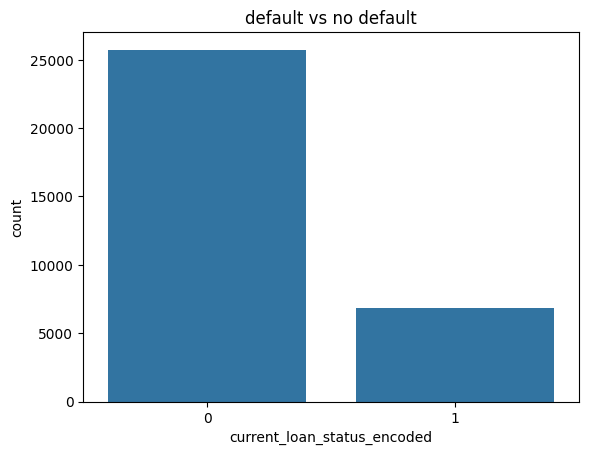

In [439]:
sns.countplot(x='current_loan_status_encoded',data=df)
plt.title('default vs no default')
plt.show()

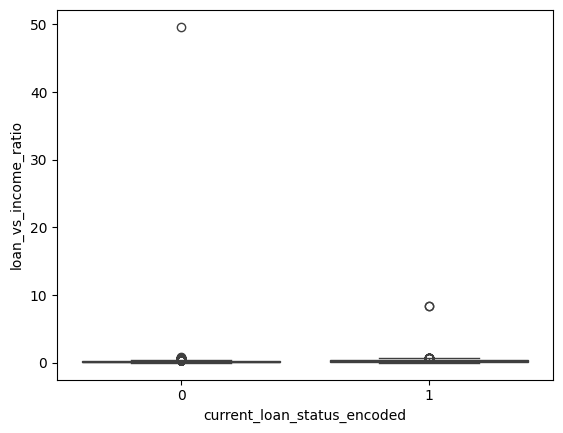

In [440]:
sns.boxplot(x='current_loan_status_encoded',y='loan_vs_income_ratio',data=df)
plt.show()

In [441]:
df['loan_vs_income_ratio']=df['loan_vs_income_ratio'].clip(upper=5)

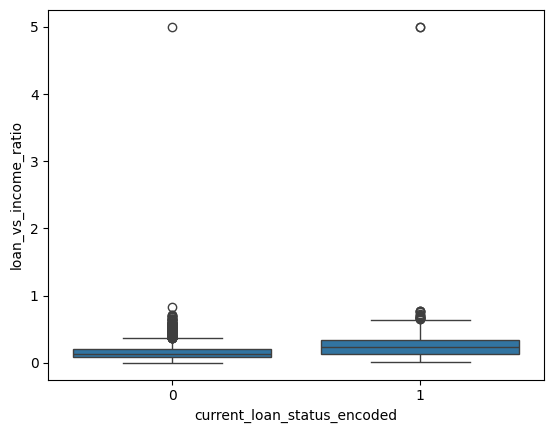

In [442]:
sns.boxplot(x='current_loan_status_encoded',y='loan_vs_income_ratio',data=df)
plt.show()

In [443]:
df.head()

,customer_age,customer_income,employment_duration,loan_grade,loan_amnt,term_years,cred_hist_length,historical_default_missing,historical_default_encoded,current_loan_status_encoded,...,home_ownership_OWN,home_ownership_RENT,loan_vs_income_ratio,customer_income_category_B,customer_income_category_C,customer_income_category_D,customer_income_category_E,load_of_loan_yearly,loan_int_rate_decimal,Total_loan_paid_with_interest
1,21,9600.0,1.791759,1,1000.0,1,2,1,-1,0,...,True,False,0.104167,False,False,False,True,1000.0,0.1114,11140.0
2,25,9600.0,0.693147,2,5500.0,5,3,0,0,1,...,False,False,0.572917,False,False,False,True,1100.0,0.1287,353925.0
3,23,65500.0,1.609438,2,35000.0,10,2,0,0,1,...,False,True,0.534351,False,False,False,False,3500.0,0.1523,5330500.0
4,24,54400.0,2.197225,2,35000.0,10,4,0,1,1,...,False,True,0.643382,True,False,False,False,3500.0,0.1427,4994500.0
5,21,9900.0,1.098612,1,2500.0,1,2,0,0,1,...,True,False,0.252525,False,False,False,True,2500.0,0.0714,17850.0


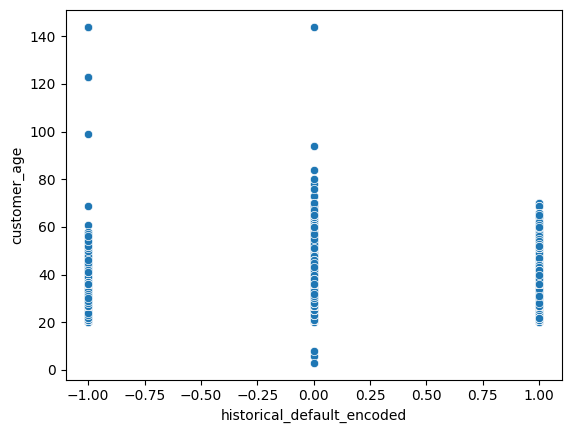

In [444]:
sns.scatterplot(x='historical_default_encoded',y='customer_age',data=df)
plt.show()

In [445]:
df['customer_age'].describe()

,customer_age
count,32576.000000
mean,27.733086
std,6.361213
min,3.000000
25%,23.000000
50%,26.000000
75%,30.000000
max,144.000000


In [446]:
df['customer_age'].isnull().sum()

np.int64(0)

In [447]:
df[df['customer_age']>100].shape[0]

5

In [448]:
df['customer_age']=df['customer_age'].clip(upper=100)

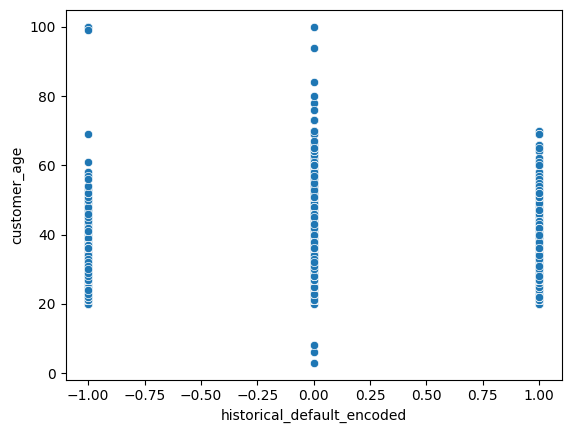

In [449]:
sns.scatterplot(x='historical_default_encoded',y='customer_age',data=df)
plt.show()

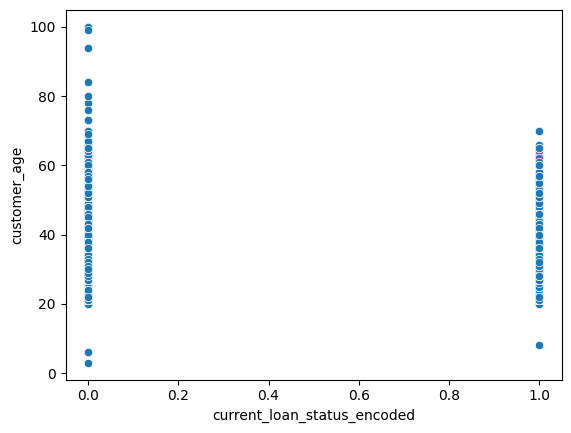

In [450]:
sns.scatterplot(x='current_loan_status_encoded',y='customer_age',data=df)
plt.show()

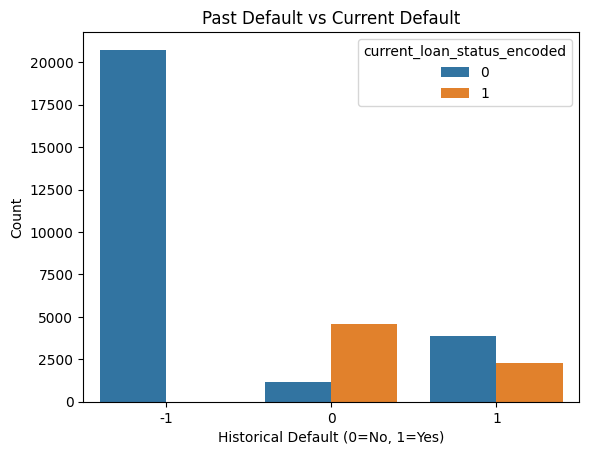

In [451]:
sns.countplot(x='historical_default_encoded',
              hue='current_loan_status_encoded',
              data=df)

plt.title("Past Default vs Current Default")
plt.xlabel("Historical Default (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()

##Implement the ML model: Logistic Regression in the dataset for traing and testing using Scikit-Learn

In [452]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


In [453]:
df.columns

Index(['customer_age', 'customer_income', 'employment_duration', 'loan_grade',
       'loan_amnt', 'term_years', 'cred_hist_length',
       'historical_default_missing', 'historical_default_encoded',
       'current_loan_status_encoded', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'home_ownership_OTHER',
       'home_ownership_OWN', 'home_ownership_RENT', 'loan_vs_income_ratio',
       'customer_income_category_B', 'customer_income_category_C',
       'customer_income_category_D', 'customer_income_category_E',
       'load_of_loan_yearly', 'loan_int_rate_decimal',
       'Total_loan_paid_with_interest'],
      dtype='object')

##The target column is 'current loan status' which is "Y" dependent variable and others column will consider as the Features so X include all the other column as features

In [454]:
x=df.drop('current_loan_status_encoded',axis=1)
y=df['current_loan_status_encoded']

##Test size for testing is 20%of the dataset

In [455]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

Transforming the X_train data using standardscaler

In [456]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

##Applying the Logistic Regression model

In [457]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

##y_pred will predict the model on X-test (the test data)

In [458]:
y_pred = model.predict(X_test)

##Checking the accuracy of the model

In [459]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9439840392879066

Confusion Matrix:
[[4991  151]
 [ 214 1160]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      5142
           1       0.88      0.84      0.86      1374

    accuracy                           0.94      6516
   macro avg       0.92      0.91      0.91      6516
weighted avg       0.94      0.94      0.94      6516



##Accuracy
Accuracy: 94.39%
This means:
The model correctly predicted 94.39% of total cases
Out of 6516 observations, most predictions are correct
##Explanation:
4991 (True Negative)
Correctly predicted non-default cases
151 (False Positive)
Predicted default, but actually non-default
214 (False Negative)
Predicted non-default, but actually default
This is risky in real-world (missed defaulters)
1160 (True Positive)
Correctly predicted default cases
##Classification Report Explanation
Class 0 (Non-default)
Precision: 0.96
96% of predicted non-defaults are correct
Recall: 0.97
Model captures 97% of all actual non-defaults
F1-score: 0.96
Balanced performance
##Class 1 (Default)(Important class)
Precision: 0.88
88% of predicted defaults are correct
Recall: 0.84
Model detects only 84% of actual defaulters
Some defaulters are missed
F1-score: 0.86


##Applying Decision tree model on the dtaset and then check the accuracy score and model performance

In [460]:
from sklearn.tree import DecisionTreeClassifier

In [461]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [462]:
y_pred_tree = tree_model.predict(X_test)

In [463]:
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Accuracy: 0.9584100675260896
[[5010  132]
 [ 139 1235]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      5142
           1       0.90      0.90      0.90      1374

    accuracy                           0.96      6516
   macro avg       0.94      0.94      0.94      6516
weighted avg       0.96      0.96      0.96      6516



##Accuracy
Accuracy: 95.84%
The model correctly predicts 95.84% of total observations, showing a strong overall performance improvement compared to the previous model(logistic regression)
##Explanation:
5010 (True Negative)
Correctly predicted non-default customers
132 (False Positive)
Predicted default, but actually non-default
139 (False Negative)
Predicted non-default, but actually default
These are risky cases (missed defaulters), but fewer than before
1235 (True Positive)
Correctly predicted default customers
##Classification Report Explanation
Class 0 (Non-default)
Precision: 0.97
97% of predicted non-defaults are correct
Recall: 0.97
Model captures 97% of all actual non-defaults
F1-score: 0.97
overall improved balanced performance than Logistic Regression
##Class 1 (Default) (Critical class)
Precision: 0.90
90% of predicted defaulters are correct
Recall: 0.90
Model successfully identifies 90% of actual defaulters
Significant improvement from previous model
F1-score: 0.90
Strong balance between precision and recall

In [464]:
tree_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

##Deapth size set to 5 to avoid overfiiting

In [465]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [466]:
y_pred_tree = tree_model.predict(X_test)

In [467]:
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Accuracy: 0.9584100675260896
[[5010  132]
 [ 139 1235]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      5142
           1       0.90      0.90      0.90      1374

    accuracy                           0.96      6516
   macro avg       0.94      0.94      0.94      6516
weighted avg       0.96      0.96      0.96      6516



##Checking the Model Prediction and Performance on New Dataset

In [468]:


new_data = pd.DataFrame([{
    'customer_age': 30,
    'customer_income': 90000,
    'employment_duration': 2.0,
    'loan_grade': 2,
    'loan_amnt': 5000,
    'term_years': 3,
    'cred_hist_length': 5,
    'historical_default_missing': 0,
    'historical_default_encoded': 0,

    'loan_intent_EDUCATION': 0,
    'loan_intent_HOMEIMPROVEMENT': 0,
    'loan_intent_MEDICAL': 0,
    'loan_intent_PERSONAL': 1,
    'loan_intent_VENTURE': 0,

    'home_ownership_OTHER': 0,
    'home_ownership_OWN': 1,
    'home_ownership_RENT': 0,

    'loan_vs_income_ratio': 5000 / 90000,

    'customer_income_category_B': 1,
    'customer_income_category_C': 0,
    'customer_income_category_D': 0,
    'customer_income_category_E': 0,

    'load_of_loan_yearly': 5000 / 3,

    'loan_int_rate_decimal': 0.12,

    'Total_loan_paid_with_interest': 5000 * 0.12 * 3
}])

adding the data into the feature 'x'

In [469]:

new_data = new_data[x.columns]

Transforming the data using scalar.transform

In [470]:
new_data_scaled = scaler.transform(new_data)

Predicting the output on new data

In [471]:
prediction = model.predict(new_data_scaled)
print("Prediction:", prediction)

Prediction: [0]


Probability on being deafulter or non defaulter

In [472]:
prob = model.predict_proba(new_data_scaled)
print("Probability:", prob)

Probability: [[0.83035115 0.16964885]]


##Probability of defaulter 0 and non defaulter 1